<!-- Trabalho Desenvolvido na Data Science Academy - www.datascienceacademy.com.br -->
# <font color='blue'>Data Science Academy</font>
# <font color='blue'>Fundamentos de Linguagem Python - Do Básico a Aplicações de IA</font>
# <font color='blue'>Lista 5 de Exercícios</font>

**ATENÇÃO**: Esta lista de exercícios pode requerer pesquisa complementar. A solução será apresentada no próximo capítulo.

In [1]:
# Imports
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

#### Exercício 1: Análise de Distribuição de Receita Mensal

- Contexto: Uma loja online deseja entender a variabilidade das receitas mensais para ajustar seu fluxo de caixa.

- Tarefa: Carregue os dados simulados de receita mensal e apresente um relatório com média, mediana, desvio-padrão, assimetria e curtose. Visualize a distribuição e interprete se ela é simétrica, à direita ou à esquerda.

- Resultado esperado: Descreva a tendência central e a dispersão, comente se a média representa bem o conjunto.

In [2]:
# Seed
np.random.seed(10)

# Cria dados de receita
receita = np.random.normal(50000, 8000, 100)

# Cria o dataframe
df = pd.DataFrame({'Receita': receita})

# Visualiza os dados
df.head()

,Receita
0,60652.692033
1,55722.231795
2,37636.797663
3,49932.929201
4,54970.687791


In [3]:
# Solução
df.describe()

,Receita
count,100.000000
mean,50635.333303
std,7775.289947
min,32946.303132
25%,46128.766733
50%,50754.947314
75%,55377.709347
max,69741.208451


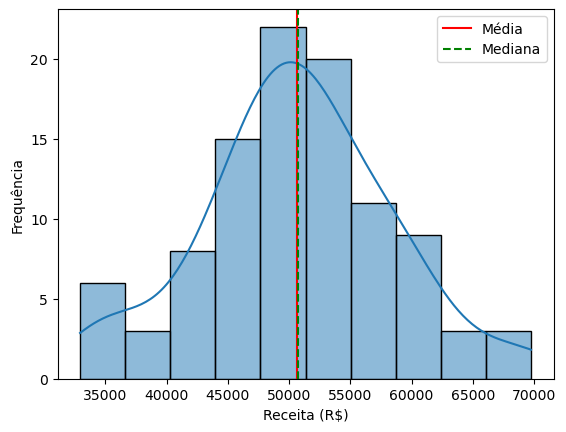

In [4]:
# gráfico

#sns.set_style('whitegrid')
#plt.rcParams['figure.figsize'] = (10,6)

sns.histplot(df['Receita'], kde = True)
plt.xlabel('Receita (R$)')
plt.ylabel('Frequência')
plt.axvline(df['Receita'].mean(), color='red', linestyle='-', label='Média')
plt.axvline(df['Receita'].median(), color='green', linestyle='--', label='Mediana')
plt.legend()
plt.show()
#sns.boxplot(df)

In [5]:
from scipy import stats

In [6]:
# estatística básica
print('\n--- Estudo estatístico do saldo mensal ---\n')
print(f'Média: {df['Receita'].mean():.2f}')
print(f'Mediana: {df['Receita'].median():.2f}')
print(f'desvio padrão: {df['Receita'].std():.2f}')

# comparação simples para deduzir por cima a assimentria [média - mediana]
media = df['Receita'].mean()
mediana = df['Receita'].median()
dif = media - mediana 
print('\n--- Diferença [média - mediana] ---\n')
print(f'Relação média - mediana: {abs(dif):.2f}')

# Descobrindo a assimentria
print('\n--- Assimetria ---\n')
print(f'Assimentia: {stats.skew(df['Receita'])}')

# Descobrindo a curtose
print('\n--- Curtose ---\n')
print(f'Curtose: {stats.kurtosis(df['Receita'])}')


--- Estudo estatístico do saldo mensal ---

Média: 50635.33
Mediana: 50754.95
desvio padrão: 7775.29

--- Diferença [média - mediana] ---

Relação média - mediana: 119.61

--- Assimetria ---

Assimentia: 0.013640630909287537

--- Curtose ---

Curtose: 0.1245315454054845


### Relatório:
A receita mensal segue de forma consistente uma distribuição aproximadamente normal, simétrica, sem outliers relevantes puxando a curva pra nenhum lado — e por isso, a média é sim uma boa representante do valor típico desse conjunto (lembra a resposta que você mesmo deu lá atrás — média só "engana" quando tem assimetria/outliers fortes, que não é o caso aqui).

#### Exercício 2: Desempenho por Segmento de Cliente

- Contexto: Uma empresa quer comparar o valor médio gasto por clientes novos e antigos.

- Tarefa: Para os dois grupos (clientes novos e antigos), calcule média, mediana e desvio-padrão, e compare visualmente com boxplot. Discuta se há sobreposição entre os grupos e qual apresenta maior variabilidade.

- Resultado esperado: Indique diferenças de média e dispersão, e o que isso sugere sobre o perfil de gasto.

In [7]:
# Seed
np.random.seed(5)

# Dataframe
clientes = pd.DataFrame({
    'Grupo': ['Novo']*80 + ['Antigo']*80,
    'Gasto': np.concatenate([np.random.normal(180, 40, 80),
                             np.random.normal(230, 35, 80)])
})

# Visualiza os dados
clientes.sample(10)

,Grupo,Gasto
122,Antigo,216.853270
119,Antigo,229.406914
143,Antigo,207.787163
40,Novo,167.765879
4,Novo,184.384394
27,Novo,165.467565
150,Antigo,279.075832
106,Antigo,200.373598
82,Antigo,256.100443
50,Novo,236.535921


In [8]:
# Solução
# Realizando analises por agrupamento:
print('\n--- Análises estatísticas descritivas:  ---\n')
print(f'media: {clientes.groupby('Grupo')['Gasto'].mean()}\n')
print(f'mediana: {clientes.groupby('Grupo')['Gasto'].median()}\n')
print(f'desvio padrão: {clientes.groupby('Grupo')['Gasto'].std()}\n')


--- Análises estatísticas descritivas:  ---

media: Grupo
Antigo    232.921448
Novo      182.692648
Name: Gasto, dtype: float64

mediana: Grupo
Antigo    231.443713
Novo      177.481971
Name: Gasto, dtype: float64

desvio padrão: Grupo
Antigo    38.388523
Novo      38.652415
Name: Gasto, dtype: float64



In [9]:
# outra forma de consultar a analise estatística
round(clientes.groupby('Grupo')['Gasto'].agg(['mean', 'median', 'std', 'sum']), 2)

,mean,median,std,sum
Grupo,,,,
Antigo,232.92,231.44,38.39,18633.72
Novo,182.69,177.48,38.65,14615.41


In [10]:
diferenca_antigo = ((18633.72 - 14615.41) * 100 / 14615.41)
diferenca_novo = ((18633.72 - 14615.41) * 100 / 18633.72)
print(f'diferença percentual de quanto o grupo antigo é maior que o grupo novo: {diferenca_antigo:.2f} %' )
print(f'diferença percentual de quanto o grupo novo é menor que o grupo antigo: {diferenca_novo:.2f} %')

diferença percentual de quanto o grupo antigo é maior que o grupo novo: 27.49 %
diferença percentual de quanto o grupo novo é menor que o grupo antigo: 21.56 %


<function matplotlib.pyplot.show(close=None, block=None)>

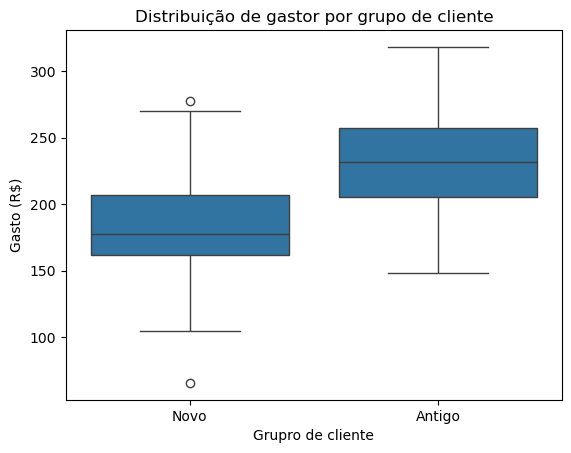

In [11]:
# Conferindo o gráfico boxplot

sns.boxplot(data= clientes,x= 'Grupo', y= 'Gasto')
plt.title('Distribuição de gastor por grupo de cliente')
plt.xlabel('Grupro de cliente')
plt.ylabel('Gasto (R$)')
plt.show

 ### Relatório

### 1. Visão geral
- Com o objetivo de comparar o resultado entre clientes novos e antigos foram analisados dados estatísticos (média, mediana e desvio padrão) com a finalidade de comparar o comportamento de gastos entre os grupos.+ e nortear decisões com foco em reteção de novos clientes.

### 2. Metodologia
- Fora usadas ferramentas nativas do python para analise estatística (groupby, mean, median, std)
- Fora usado matplotlib e seaborn para realizar a visualização das análises gráficas

### 3. Resultados
| Grupo |mean|	median|	std	|
|:---|:---|:---|:---|
|Antigo|	232.92|	231.44|	38.39|
|Novo|	182.69|	177.48|	38.65|

![DSA](análise_atividade.png)

### 4. Interpretação
- Os dados do gráfico mostram que o o desvio padrão entre os grupos (38,39 e 38,65) é muito similiar indicando um comportamento de compra parecido entre os cliente novos e os antigos. Sugerindo que os clientes novos tem altas chances de perdurarem. O que reforça o potencial de fidelização, mas não é, por si só, evidência de retenção futura.
- Ao analisar o gráfico denota-se que a faixa superior da caixa dos clientes Novos (Q3) se sobrepõe à faixa inferior da caixa dos Antigos, reforçando que os clientes novos tem comportamento de compra similar aos de clientes antigos.
- Foi percebido a existência outlier positivo e negativo. Mostrando que não somente o tempo modifica o consumo do cliente e sim outras variáveis como experiência do cliente (seja com o time de vendas, entrega, recepção e qualidade do produto)

### 5. Recomendações - Foco na fidelização dos NEWs

1. Ao perceber que o tempo como cliente não influencia diretamente no comportamento de compra, fortalecer a experiencia do cliente com campanhas de cupons de desconto, campanha de indicação (uma vez que o cliente adotou uma confiança nos produtos) e comunicação de oferta de itens que se correlacionam com os itens adquiridos pelo cliente com o objetivo de dar suporte e melhor acessorar o cliente
2. Revisar oportunidades da experiencia do cliente, uma vez que tivemos outliers negativos, sugiro analisar pontos como:
  - Facilidade em acessar e usar os produtos
  - Acolhimento e recepção do cliente
  - Estudar se foram os valores que afastaram novos clientes
  - Como foi o pós atendimento / pós venda dos clientes outliers negativos

#### Exercício 3: Correlação Entre Horas de Estudo e Nota

- Contexto: Um professor quer saber se o tempo de estudo está associado ao desempenho dos alunos.

- Tarefa: Calcule a correlação de Pearson e gere o gráfico de dispersão com linha de regressão. Interprete o grau e a direção da relação.

- Resultado esperado: Descreva se há correlação positiva, negativa ou nula e o que isso significa em termos práticos.

In [12]:
# Seed
np.random.seed(2)

# Dados
horas = np.random.uniform(1, 10, 50)
notas = 5*horas + np.random.normal(0, 5, 50)

# Dataframe
df = pd.DataFrame({'Horas': horas, 'Nota': notas})

# Visualiza os dados
df.head()

,Horas,Nota
0,4.923954,20.474094
1,1.233336,6.605232
2,5.946962,34.736641
3,4.917902,22.684045
4,4.783310,22.038204


In [13]:
# Solução
from scipy import stats

correlacao, p_valor = stats.pearsonr(df['Horas'], df['Nota'])
print(f'Correlação de Pearson: {correlacao}')
print(f'P-valor: {p_valor}')

Correlação de Pearson: 0.9148528570908789
P-valor: 1.5536796577938903e-20


##### Como interpretar o número

- P-valor baixo (convenção: < 0.05) → é improvável que o resultado seja só coincidência → você tem confiança de que a relação é real
- P-valor alto (> 0.05) → é bem possível que o resultado seja só sorte de amostra pequena → não dá pra confiar que existe relação de verdade

###### força (correlação) e confiabilidade (p-valor).
- Correlação é um termo técnico específico: mede a relação entre duas variáveis numéricas (tipo "quanto mais X, mais Y" — ex: tempo de cadastro x valor gasto).

<function matplotlib.pyplot.show(close=None, block=None)>

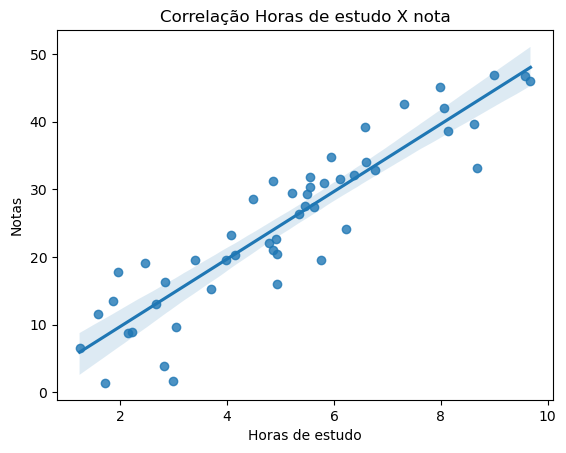

In [14]:
sns.regplot(data=df,y= 'Nota',x= 'Horas')
plt.title("Correlação Horas de estudo X nota")
plt.xlabel('Horas de estudo')
plt.ylabel('Notas')
plt.show

### Relatório:

> Ao analisar a correlação de person (0.91, indicando forte correlação) tivemos uma forte tendencia de quanto mais horas estudadas maior será a nota. E essa correlação é validada pelo p-valor (muito menor que 0.05, aproximadamente 1.55 x 10^-20). 

> Foi analisado no gráfico (regplot) que existem estudantes com a mesma quantidade de horas de estudo e com nota inferior a de seus colegas com a mesma quantidade de horas estudadas, demostrando que existe uma possível correlação de qualidade e/ou tecnicas de estudo a ser analisada.

#### Exercício 4: Variação Semanal de Vendas

- Contexto: O gestor deseja entender como as vendas variam ao longo da semana.

- Tarefa: Simule dados de vendas diárias, calcule média e desvio por dia da semana e gere um gráfico de barras. Interprete os dias de maior e menor performance.

- Resultado esperado: Identifique os dias mais fortes e mais fracos, e comente sobre a estabilidade semanal das vendas.

In [15]:
# Seed
np.random.seed(3)

# Dados
dias = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sab', 'Dom']
vendas = pd.DataFrame({
    'Dia': np.random.choice(dias, 200),
    'Vendas': np.random.normal(1000, 150, 200)
})

# Visualiza os dados
vendas.head()

,Dia,Vendas
0,Qua,911.338189
1,Seg,922.537395
2,Ter,856.000573
3,Qui,1056.594285
4,Seg,913.793737


In [16]:
# Solução
vendas_dia = vendas.groupby('Dia')["Vendas"].agg(['mean','std'])
display(round(vendas_dia,2))

,mean,std
Dia,,
Dom,1034.72,161.90
Qua,1009.72,134.50
Qui,1027.47,196.07
Sab,1021.63,133.61
Seg,1008.34,121.90
Sex,1049.79,152.09
Ter,990.27,142.26


<function matplotlib.pyplot.show(close=None, block=None)>

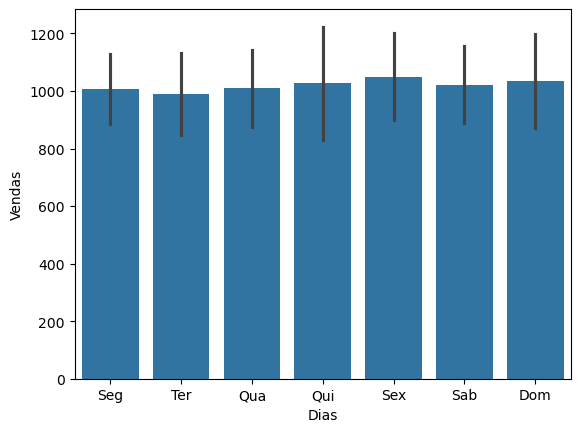

In [17]:
ordem_dias =  ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sab', 'Dom']
sns.barplot(data=vendas, x='Dia', y='Vendas', errorbar='sd', order= ordem_dias)
plt.xlabel("Dias")
plt.ylabel('Vendas')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

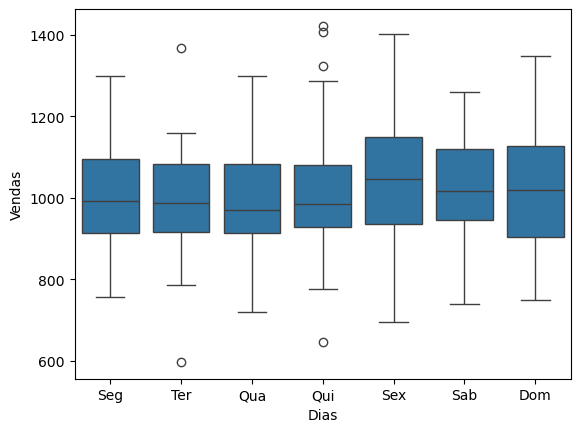

In [18]:
sns.boxplot(data= vendas ,x='Dia', y='Vendas', order= ordem_dias)
plt.xlabel("Dias")
plt.ylabel('Vendas')
plt.show

In [19]:
# Uma outra boa prática é usar o categorical para ordenar valores categóricos
# Desse modo sempre serão ordenados os dias da semana independente do gráfico que seja usado e da quantidade de gráficos.

ordem_dias = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sab', 'Dom']

vendas['Dia'] = pd.Categorical(vendas['Dia'], categories=ordem_dias, ordered=True)
display(vendas_dia)

,mean,std
Dia,,
Dom,1034.716174,161.899699
Qua,1009.722472,134.496526
Qui,1027.466786,196.069107
Sab,1021.630030,133.611346
Seg,1008.344683,121.895506
Sex,1049.790137,152.085006
Ter,990.271715,142.264723


In [20]:
contando_dias = vendas['Dia'].value_counts()
cont_d = sum(vendas['Dia'].value_counts())
print(f'Total de dias: {cont_d}\n')
display(contando_dias)

Total de dias: 200



Dia
Seg    41
Sex    39
Ter    28
Qua    28
Sab    24
Qui    23
Dom    17
Name: count, dtype: int64

In [21]:
cont_d = sum(vendas['Dia'].value_counts())
print(cont_d)

200


> Gráfico de barras → mostra um resumo único por categoria (geralmente a média), com foco em comparação direta de magnitude. Bom quando você quer responder "qual dia vende mais/menos" de forma simples e direta.
> 
> Boxplot → mostra a distribuição completa por categoria (mediana, quartis, outliers). Melhor quando o foco é entender variabilidade/dispersão dentro de cada grupo, como fizemos na questão 2.

[Text(0, 0, '1008'),
 Text(0, 0, '990'),
 Text(0, 0, '1010'),
 Text(0, 0, '1027'),
 Text(0, 0, '1050'),
 Text(0, 0, '1022'),
 Text(0, 0, '1035')]

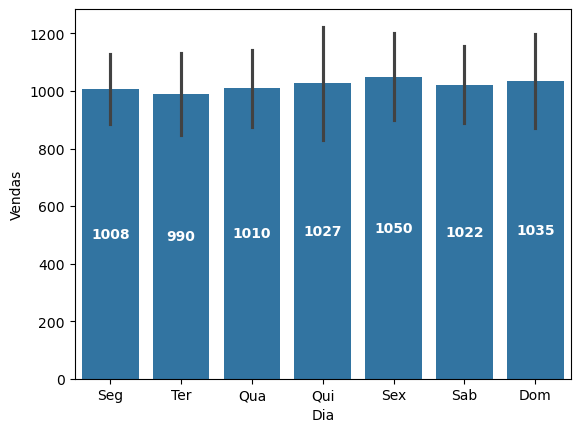

In [22]:
# gráfico enriquecido 1

ax = sns.barplot(data=vendas, x='Dia', y='Vendas', errorbar='sd', order=ordem_dias)
ax.bar_label(ax.containers[0], fmt='%.0f', label_type='center', color = 'white', fontweight='bold')

<Axes: xlabel='Dia', ylabel='Vendas'>

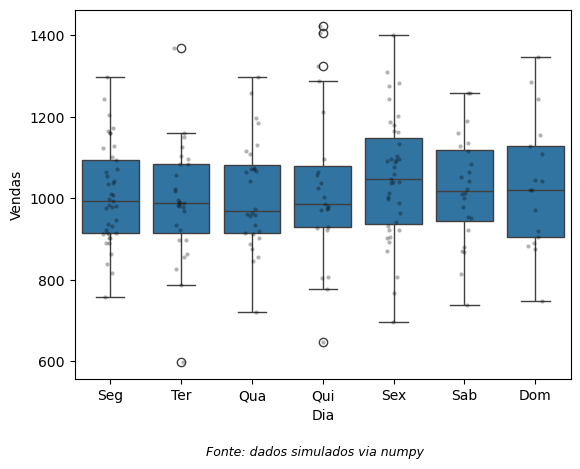

In [23]:
# gráfico enriquecido 2
sns.boxplot(data=vendas, x='Dia', y='Vendas', order=ordem_dias)
plt.figtext(0.5, -0.05, 'Fonte: dados simulados via numpy', ha='center', fontsize=9, style='italic')
sns.stripplot(data=vendas, x='Dia', y='Vendas', order=ordem_dias, color='black', alpha=0.3, size=3)

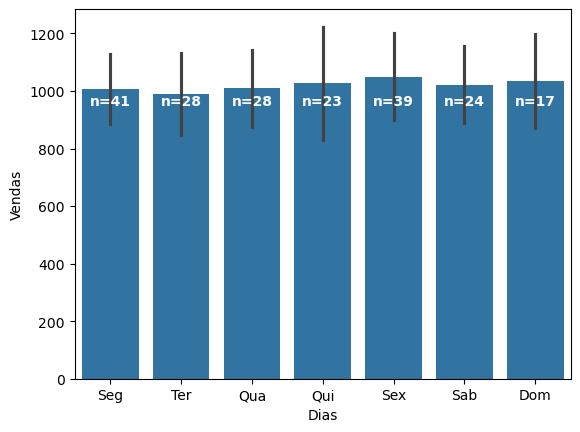

In [24]:
# gráfico enriquecido 3
ax = sns.barplot(data=vendas, x='Dia', y='Vendas', errorbar='sd', order=ordem_dias)
plt.xlabel("Dias")
plt.ylabel('Vendas')

contagem = vendas['Dia'].value_counts().reindex(ordem_dias)
for i, n in enumerate(contagem):
    plt.text(i, 950, f'n={n}', ha='center', color='white', fontweight='bold')

plt.show()

## Mini Relatório — Variação Semanal de Vendas

### 1. Contexto
O gestor solicitou entender como as vendas diárias variam ao longo dos dias da semana, buscando identificar dias de maior e menor performance, e avaliar a estabilidade das vendas.

### 2. Metodologia
Base de 200 registros de vendas diárias, distribuídos aleatoriamente entre os 7 dias da semana. Foram calculadas média, desvio-padrão e quantidade de observações (n) por dia via `groupby()`. A visualização foi feita com gráfico de barras (média + barra de erro representando desvio-padrão) e complementada com boxplot + stripplot para inspeção da distribuição individual.

### 3. Resultados

| Dia | Média (aprox.) | Desvio-padrão | n (observações) |
|---|---|---|---|
| Seg | 1008 | 121,90 | 41 |
| Ter | 990 | 142,26 | 28 |
| Qua | 1010 | 134,5 | 28 |
| Qui | 1027 | 196,07 | 23 |
| Sex | 1050 | 152,09 | 39 |
| Sab | 1022 | 133,61 | 24 |
| Dom | 1035 | 161,90 | 17 |

**[Inserir aqui: gráfico de barras com error bar e labels de n]**
**[Inserir aqui: boxplot com stripplot]**

### 4. Interpretação

- As médias de vendas variam pouco entre os dias (faixa de 990 a 1050), sem nenhum dia se destacando de forma decisiva como "mais forte" ou "mais fraco" em termos de valor médio vendido.
- A quantidade de observações (n) varia consideravelmente entre os dias — de 17 (Domingo) a 41 (Segunda) — refletindo a aleatoriedade da geração dos dados, não um padrão real de negócio.
- Existe uma leve tendência de dias com menor n (Quinta, Domingo) apresentarem maior variabilidade aparente no desvio-padrão, mas essa relação não é perfeitamente consistente: Sábado, com n semelhante ao de Quinta, apresenta variabilidade bem menor. Isso indica que o tamanho da amostra explica parte da diferença de dispersão entre os dias, mas não toda ela — o restante é ruído estatístico natural.
- O boxplot com stripplot confirma que a distribuição de vendas em cada dia é razoavelmente simétrica, sem concentrações ou lacunas incomuns nos pontos individuais.

### 5. Conclusão
As vendas são estatisticamente estáveis ao longo da semana, sem um dia de desempenho claramente superior ou inferior aos demais. As diferenças de variabilidade observadas entre os dias devem ser interpretadas com cautela, já que parte delas decorre do tamanho desigual das amostras por dia, e não de um comportamento real de consumo distinto entre os dias da semana.

### 6. Recomendação
Não há evidência estatística suficiente para direcionar ações comerciais específicas por dia da semana (como reforço de equipe ou promoções direcionadas) com base apenas nesses dados. Caso o gestor deseje investigar variações reais entre dias, recomenda-se coletar uma amostra com quantidade de observações equilibrada por dia, evitando que diferenças de n influenciem a leitura de variabilidade.


#### Exercício 5: Estimativa da Média com Intervalo de Confiança (Statsmodels)

- Contexto: Um analista de RH quer estimar a altura média dos colaboradores com 95% de confiança.

- Tarefa: Calcule a média e o intervalo de confiança usando o DescrStatsW do Statsmodels. Interprete o resultado como se fosse parte de um relatório técnico.

- Resultado esperado: Apresente a altura média estimada e explique o significado do intervalo de confiança no contexto da amostra.

In [25]:
# Seed
np.random.seed(7)

# Conjunto de dados
alturas = np.random.normal(1.75, 0.08, 40)

# Visualiza os dados
alturas

array([1.88524206, 1.71272501, 1.75262561, 1.7826013 , 1.68688616,
       1.75016525, 1.74992877, 1.60962206, 1.83141264, 1.79803988,
       1.69996568, 1.73627614, 1.79042395, 1.72909149, 1.73058007,
       1.63374069, 1.79436642, 1.75991047, 1.77195679, 1.62787804,
       1.88205598, 1.76234684, 1.7190288 , 1.91232578, 1.74636912,
       1.6339457 , 1.71758177, 1.56693479, 1.83395172, 1.71668205,
       1.69059572, 1.83579761, 1.61791395, 1.79283435, 1.58484682,
       1.69702725, 1.65366241, 1.86695805, 1.89129287, 1.7236469 ])

In [26]:
# Solução
from statsmodels.stats.weightstats import DescrStatsW

stats_altura = DescrStatsW(alturas)
media = stats_altura.mean
intervalo = stats_altura.tconfint_mean(alpha=0.05)

#lendo o resultado

print(intervalo)
print(f'Altura média estimada: {media:.2f} m')
print(f'Intervalo de confiança de 95%: [{intervalo[0]:.2f} m, {intervalo[1]:.2f} m]')

(np.float64(1.7143126677074148), np.float64(1.7696491810206263))
Altura média estimada: 1.74 m
Intervalo de confiança de 95%: [1.71 m, 1.77 m]


>amplitude_dados = maior_valor - menor_valor

>amplitude_dados = 1.7696491810206263 - 1.7143126677074148

>amplitude_dados ≈ 0.05533651331

## Mini Relatório — Estimativa da Altura Média com Intervalo de Confiança

### 1. Contexto
O setor de RH solicitou a estimativa da altura média dos colaboradores, com 95% de confiança, a partir de uma amostra de 40 colaboradores.

### 2. Metodologia
Foi utilizada a classe `DescrStatsW` do Statsmodels para calcular a média amostral e o intervalo de confiança de 95% (`alpha=0.05`), com base no método `tconfint_mean()`.

```python
from statsmodels.stats.weightstats import DescrStatsW

stats_altura = DescrStatsW(alturas)
media = stats_altura.mean
intervalo = stats_altura.tconfint_mean(alpha=0.05)
```

### 3. Resultados

| Métrica | Valor |
|---|---|
| Tamanho da amostra (n) | 40 |
| Altura média estimada | 1,74 m |
| Intervalo de confiança (95%) | [1,71 m ; 1,77 m] |
| Amplitude do intervalo | ≈ 0,055 m (5,5 cm) |

### 4. Interpretação

- A altura média estimada dos colaboradores é de **1,74 m**, com um intervalo de confiança de 95% entre **1,71 m e 1,77 m**.
- Isso significa que, caso o processo de amostragem fosse repetido diversas vezes com diferentes grupos de 40 colaboradores, espera-se que o intervalo calculado contenha a verdadeira média populacional em 95% dessas repetições. O nível de confiança descreve a confiabilidade do método de estimativa, não uma garantia sobre essa amostra específica isoladamente.
- O intervalo encontrado é relativamente estreito (~5,5 cm de amplitude) quando comparado à variação bruta observada nos dados individuais (que variam de aproximadamente 1,57 m a 1,91 m, ~34 cm de amplitude). Isso ocorre porque o intervalo de confiança da média é afetado pelo erro padrão (desvio-padrão dividido pela raiz do tamanho da amostra), e não pela dispersão bruta dos dados — amostras maiores tendem a produzir intervalos mais estreitos, mesmo mantendo o mesmo desvio-padrão individual.

### 5. Conclusão
Com 95% de confiança, estima-se que a altura média real da população de colaboradores esteja entre 1,71 m e 1,77 m. O resultado é consistente com uma amostra de tamanho moderado (n=40) extraída de uma população com variabilidade individual moderada (desvio-padrão aproximado de 8 cm).

### 6. Recomendação
Para reduzir a amplitude do intervalo de confiança e aumentar a precisão da estimativa (caso necessário para decisões de RH, como dimensionamento de uniformes ou mobiliário), recomenda-se aumentar o tamanho da amostra em futuras coletas.

# Fim